# ITC Stock Analysis
# Financial Market Trend & Risk Analysis


In [24]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

In [25]:
data = yf.download("ITC.NS", start="2018-01-01")

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

data.tail()

/tmp/ipykernel_598/4003317820.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("ITC.NS", start="2018-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2026-03-09,306.000000,307.200012,303.600006,305.000000,14084931
2026-03-10,309.049988,310.000000,303.750000,309.000000,18352950
2026-03-11,309.000000,310.649994,307.700012,309.049988,14842485
2026-03-12,304.100006,308.000000,302.850006,307.049988,23319679
2026-03-13,301.450012,306.000000,300.649994,304.000000,25655940


In [26]:
data["simple_return"] = data["Close"].pct_change()

data["log_return"] = np.log(data["Close"] / data["Close"].shift(1))

data = data.dropna()

data

Price,Close,High,Low,Open,Volume,simple_return,log_return
Date,,,,,,,
2018-01-02,182.560181,184.975642,182.350137,183.855426,5907460,-0.005909,-0.005927
2018-01-03,182.840210,183.890408,182.455137,182.945232,11443370,0.001534,0.001533
2018-01-04,183.120285,183.960450,182.455161,182.700208,9729737,0.001532,0.001531
2018-01-05,184.065460,184.485537,183.365321,183.365321,9566733,0.005161,0.005148
2018-01-08,185.955841,186.796006,184.310526,184.835625,14989106,0.010270,0.010218
...,...,...,...,...,...,...,...
2026-03-09,306.000000,307.200012,303.600006,305.000000,14084931,-0.011947,-0.012019
2026-03-10,309.049988,310.000000,303.750000,309.000000,18352950,0.009967,0.009918
2026-03-11,309.000000,310.649994,307.700012,309.049988,14842485,-0.000162,-0.000162


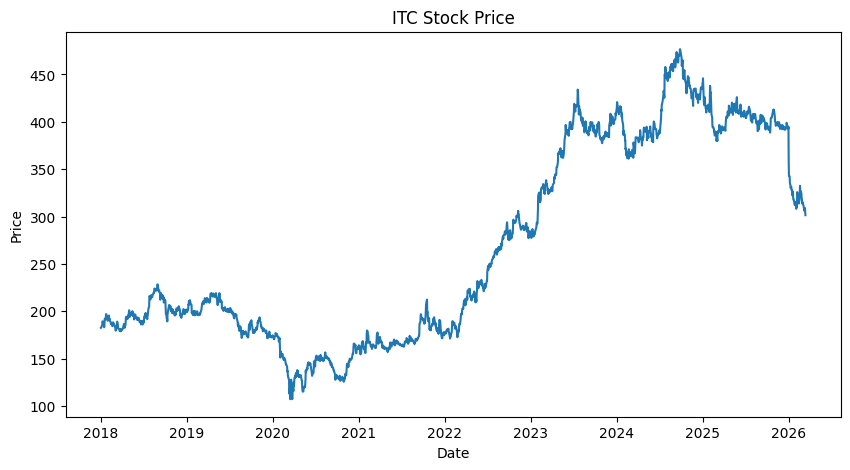

In [27]:
plt.figure(figsize=(10,5))
plt.plot(data.index, data["Close"])

plt.title("ITC Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()

## Volatility Analysis

In [28]:
daily_volatility = data["log_return"].std()

annual_volatility = daily_volatility * np.sqrt(252)

print("Daily Volatility:", daily_volatility)
print("Annual Volatility:", annual_volatility)

Daily Volatility: 0.01502535317849878
Annual Volatility: 0.23852008722732998


## Sharpe Ratio

In [29]:
annual_return = data["log_return"].mean() * 252

risk_free_rate = 0.07

sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility

print("Annual Return:", annual_return)
print("Sharpe Ratio:", sharpe_ratio)

Annual Return: 0.06167436286797719
Sharpe Ratio: -0.034905391947504104


## Beta Calculation (Market Risk)

In [30]:
market = yf.download("^NSEI", start="2018-01-01")

if isinstance(market.columns, pd.MultiIndex):
    market.columns = market.columns.get_level_values(0)

market["market_return"] = np.log(
    market["Close"] / market["Close"].shift(1)
)

combined = pd.concat([data["log_return"], market["market_return"]], axis=1).dropna()

combined.columns = ["stock_return","market_return"]

covariance = combined.cov().iloc[0,1]

market_variance = combined["market_return"].var()

beta = covariance / market_variance

print("Beta:", beta)

/tmp/ipykernel_598/1361327522.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  market = yf.download("^NSEI", start="2018-01-01")
[*********************100%***********************]  1 of 1 completed

Beta: 0.6927410770198252


## Value at Risk (VaR)

In [31]:
VaR_95 = np.percentile(data["log_return"], 5)

print("Value at Risk (95% confidence):", VaR_95)

Value at Risk (95% confidence): -0.020252981218234916


## Stationarity Test (ADF)

In [32]:
result = adfuller(data["log_return"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -13.535566600372045
p-value: 2.5717137035979668e-25


## ARIMA Model

In [33]:
model = ARIMA(data["log_return"], order=(1,0,1))

model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             log_return   No. Observations:                 2025
Model:                 ARIMA(1, 0, 1)   Log Likelihood                5630.056
Date:                Sat, 14 Mar 2026   AIC                         -11252.111
Time:                        11:04:19   BIC                         -11229.658
Sample:                             0   HQIC                        -11243.872
                               - 2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.000      0.731      0.465      -0.000       0.001
ar.L1         -0.4965      0.206     -2.412      0.016      -0.900      -0.093
ma.L1          0.4599      0.210      2.188      0.0

## Forecast Future Returns

In [34]:
forecast = model_fit.forecast(steps=5)

print("Next 5 days forecast:")
print(forecast)

Next 5 days forecast:
2025    0.000350
2026    0.000189
2027    0.000269
2028    0.000229
2029    0.000249
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


## Return Distribution

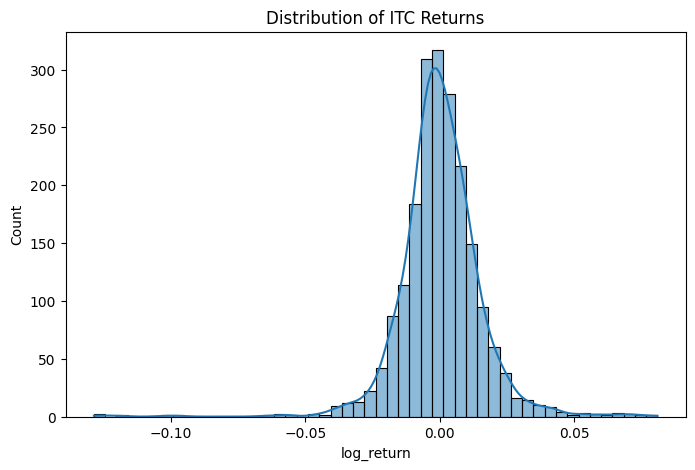

In [35]:
plt.figure(figsize=(8,5))

sns.histplot(data["log_return"], bins=50, kde=True)

plt.title("Distribution of ITC Returns")

plt.show()

## Performance Analysis using Pyfolio

In this section we analyze the performance of ITC stock using the Pyfolio library.

We compare the performance of Reliance Industries against the NIFTY 50 index.

In [36]:
!pip install pyfolio-reloaded

In [37]:
import pyfolio as pf

### Download Benchmark Data (NIFTY 50)

To evaluate the performance of the stock relative to the market, we use the NIFTY 50 index as a benchmark.

In [38]:
market = yf.download("^NSEI", start="2018-01-01")

if isinstance(market.columns, pd.MultiIndex):
    market.columns = market.columns.get_level_values(0)

market.tail()


/tmp/ipykernel_598/9588769.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  market = yf.download("^NSEI", start="2018-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2026-03-09,24028.050781,24078.150391,23697.800781,23868.050781,526900
2026-03-10,24261.599609,24303.800781,24079.949219,24280.800781,444300
2026-03-11,23866.849609,24299.000000,23834.300781,24231.849609,407400
2026-03-12,23639.150391,23833.150391,23556.300781,23674.849609,501000
2026-03-13,23151.099609,23492.400391,23112.000000,23462.500000,0


### Compute Benchmark Returns

We compute log returns for the benchmark index to ensure consistency with the stock returns used earlier.

In [39]:
market["market_return"] = np.log(
    market["Close"] / market["Close"].shift(1)
)

benchmark_returns = market["market_return"].dropna()

benchmark_returns.head()


,market_return
Date,
2018-01-03,0.000096
2018-01-04,0.005881
2018-01-05,0.005132
2018-01-08,0.006114
2018-01-09,0.001261


### Prepare Stock Returns

Pyfolio requires a clean return series indexed by datetime.

We remove timezone information and ensure the data is aligned properly.

In [40]:
returns = data["log_return"]

returns.index = returns.index.tz_localize(None)
benchmark_returns.index = benchmark_returns.index.tz_localize(None)


### Generate Pyfolio Performance Report

The Pyfolio tear sheet provides a comprehensive summary of portfolio performance including:

- cumulative returns
- drawdown periods
- rolling Sharpe ratio
- volatility analysis
- return distribution

/usr/local/lib/python3.12/dist-packages/pyfolio/plotting.py:670: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3.152%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  perf_stats.loc[stat, column] = str(np.round(value * 100, 3)) + "%"


Start date,2018-01-03
End date,2026-03-13
Total months,96
,Backtest
Annual return,3.152%
Cumulative returns,28.248%
Annual volatility,23.876%
Sharpe ratio,0.25
Calmar ratio,0.06
Stability,0.50
Max drawdown,-56.859%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,56.86,2018-08-31,2020-03-25,2022-09-02,1046
1,38.36,2024-09-26,2026-03-13,NaT,NaN
2,17.52,2023-07-20,2024-02-21,2024-07-23,264
3,9.56,2022-11-09,2022-12-23,2023-02-02,62
4,9.47,2018-01-24,2018-03-28,2018-05-02,71


/usr/local/lib/python3.12/dist-packages/pyfolio/plotting.py:1407: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Daily", "Weekly", "Monthly"])


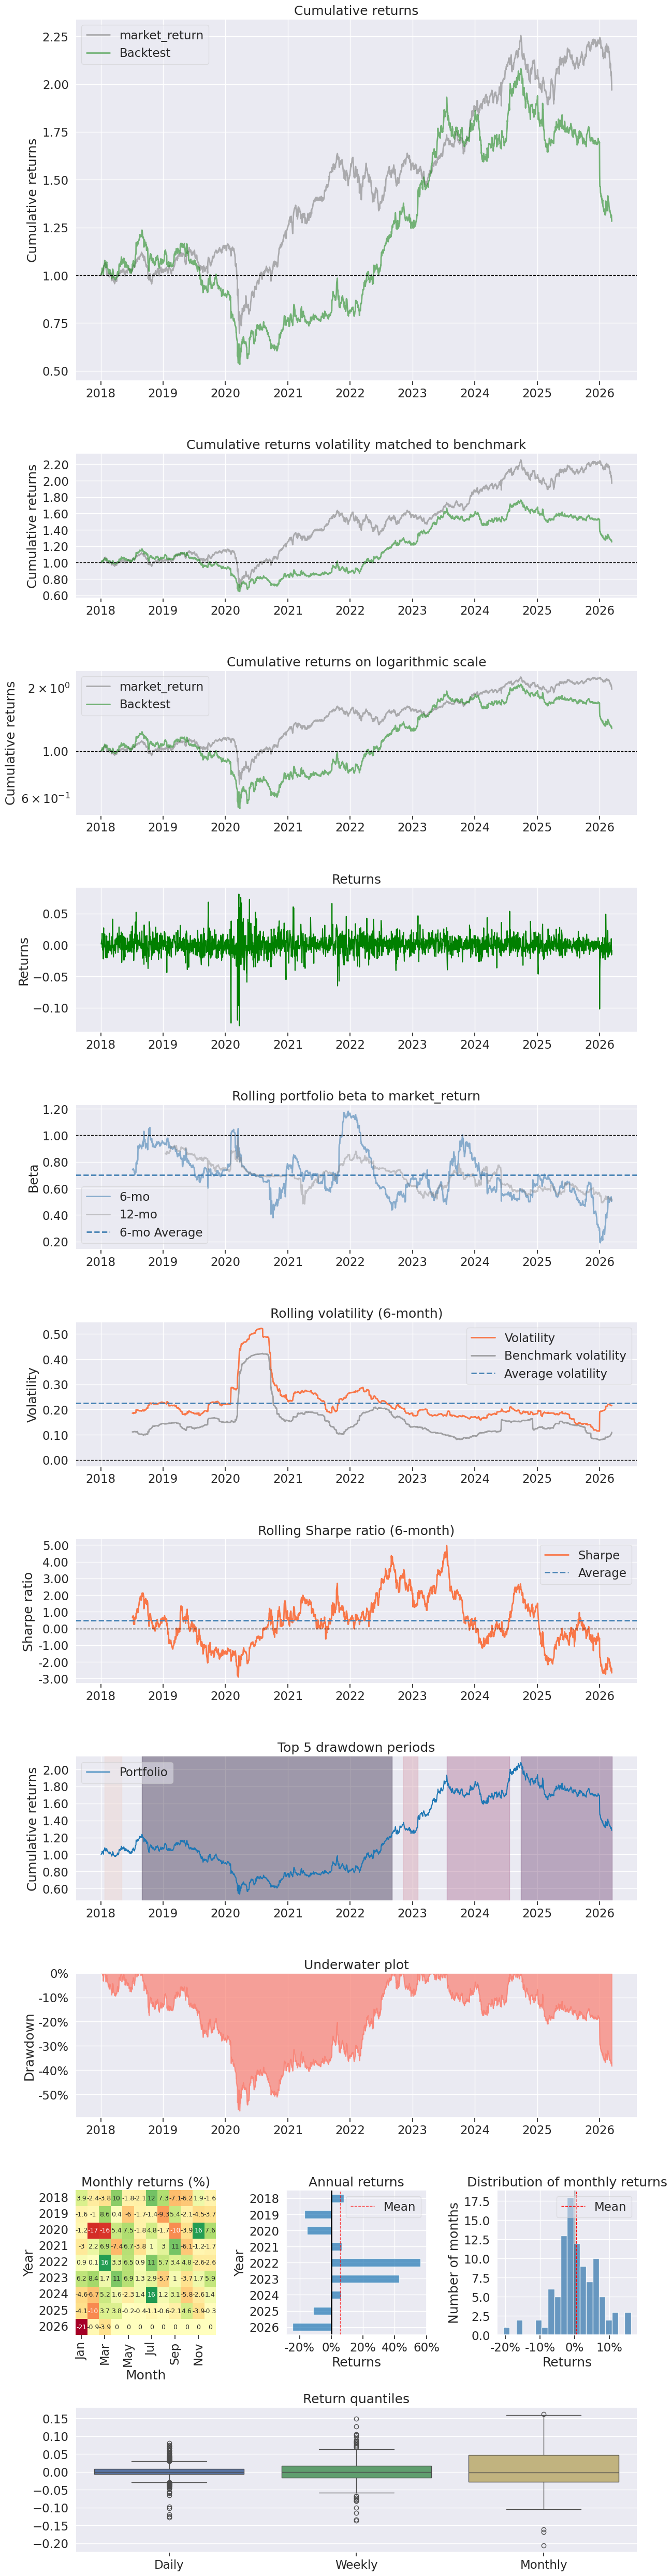

In [41]:
pf.create_returns_tear_sheet(
    returns,
    benchmark_rets=benchmark_returns
)


### Rolling Volatility

Rolling volatility helps visualize how risk evolves over time.

<Axes: title={'center': 'Rolling volatility (6-month)'}, ylabel='Volatility'>

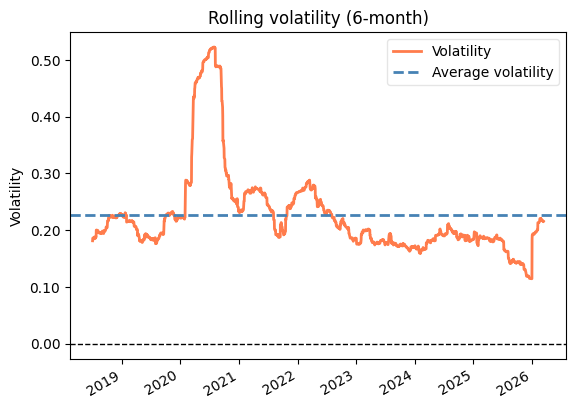

In [42]:
pf.plotting.plot_rolling_volatility(returns)


### Rolling Sharpe Ratio

This plot shows how the risk-adjusted return changes through time.

<Axes: title={'center': 'Rolling Sharpe ratio (6-month)'}, ylabel='Sharpe ratio'>

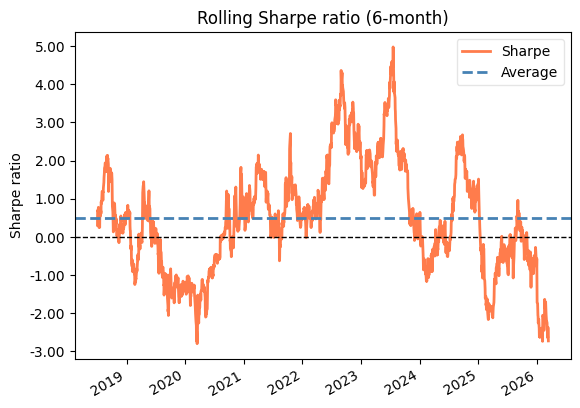

In [43]:
pf.plotting.plot_rolling_sharpe(returns)


### Drawdown Analysis

Drawdown represents the decline from a historical peak.

This helps identify periods of large losses.

<Axes: title={'center': 'Top 10 drawdown periods'}, ylabel='Cumulative returns'>

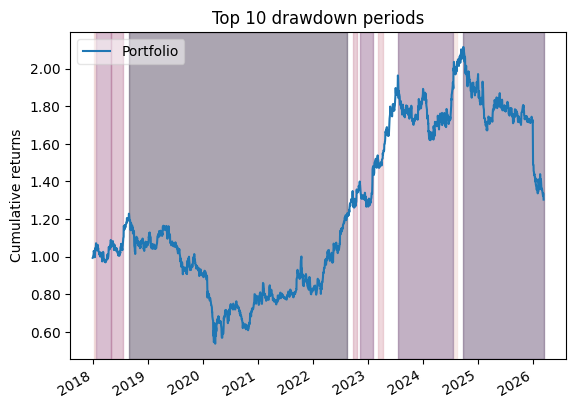

In [44]:
pf.plotting.plot_drawdown_periods(returns)


## Rolling Metrics

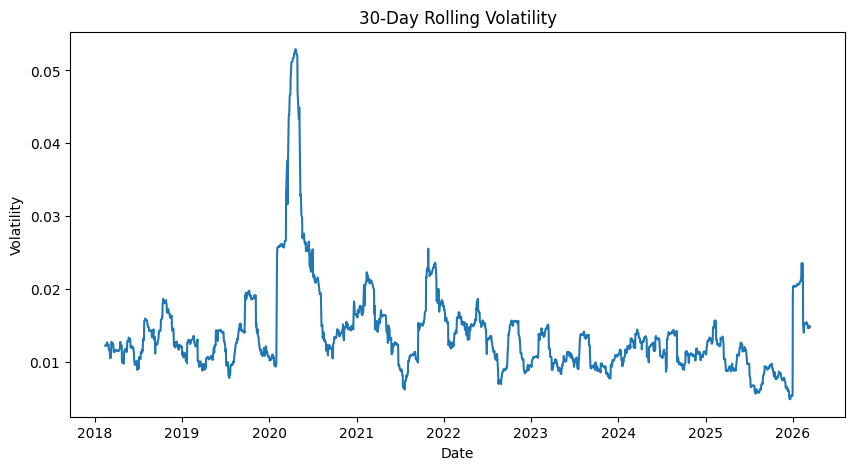

In [45]:
data["rolling_vol"] = data["log_return"].rolling(30).std()

plt.figure(figsize=(10,5))
plt.plot(data["rolling_vol"])

plt.title("30-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.show()

## Maximum Drawdown

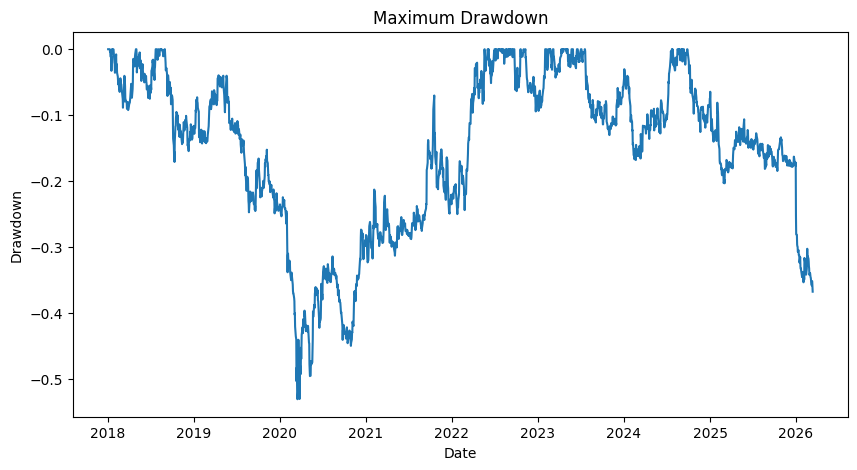

In [46]:
cum_returns = (1 + data["simple_return"]).cumprod()

rolling_max = cum_returns.cummax()

drawdown = cum_returns / rolling_max - 1

plt.figure(figsize=(10,5))
plt.plot(drawdown)

plt.title("Maximum Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")

plt.show()

## Cumulative Returns

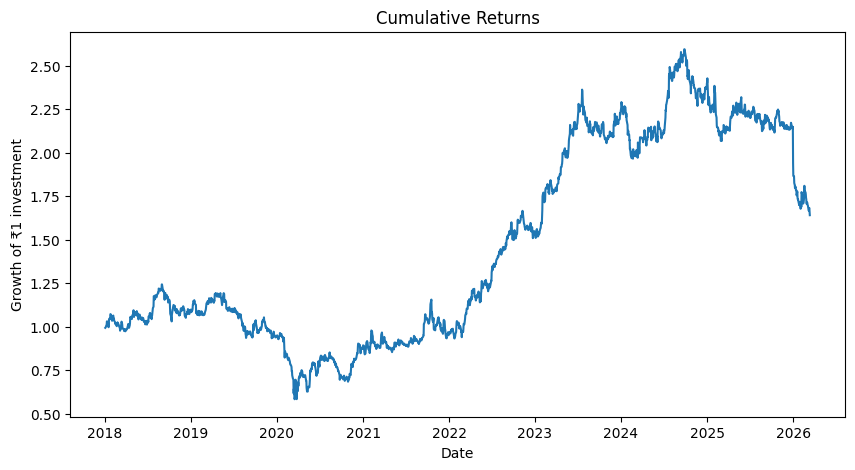

In [47]:
cum_returns = (1 + data["simple_return"]).cumprod()

plt.figure(figsize=(10,5))
plt.plot(cum_returns)

plt.title("Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Growth of ₹1 investment")

plt.show()